# 📓 Pipeline Completo de Machine Learning  
## Árvore de Decisão com o dataset hamon_googlefit_medical_realistic.csv

**Aluno:** Deeline Design  
**Modelo escolhido:** DecisionTreeClassifier  
**Objetivo:** Prever o `cardiometabolic_risk_state` (0 a 4) com dados reais de Google Fit + medidas médicas.

**Importante:** Este notebook segue a orientação do professor. O foco principal é a **explicação conceitual** de cada uma das 7 etapas do pipeline (o “porquê” e o “como”), e não apenas a execução de código. Utilizamos o dataset real fornecido para ilustrar cada etapa de forma prática.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


## Etapa 1: Coleta de Dados

**Porquê?**  
A coleta é a base de todo projeto. Dados ruins levam a modelos ruins. É essencial entender o contexto do negócio (aqui: saúde cardiometabólica monitorada por Google Fit) e verificar a qualidade inicial dos dados.

**Como foi feito?**  
Carregamos o arquivo CSV com 90.000 registros (3000 usuários × 30 dias). Realizamos uma Exploração de Dados (EDA) inicial para verificar shape, distribuição do target e valores faltantes.

Shape do dataset: (90000, 37)

Distribuição do target:
cardiometabolic_risk_state
0      791
1    27037
2    47142
3     6547
4     8483
Name: count, dtype: int64

=== Valores nulos ===
bp_systolic             54009
bp_diastolic            54009
fasting_glucose         67686
postprandial_glucose    67686
sleep_hours             22460
sleep_efficiency        22460
dtype: int64

=== ESTATÍSTICAS DESCRITIVAS ===
                                   mean          std      min           max
user_id                     1500.500000   866.030167     1.00   3000.000000
age                           48.568000    17.960223    18.00     79.000000
sex                            0.495333     0.499981     0.00      1.000000
bmi                           26.132515     4.338149    18.00     41.543209
smoking_status                 0.196000     0.396971     0.00      1.000000
family_history_cvd             0.297667     0.457235     0.00      1.000000
fitness_level                  0.803000     0.743548   

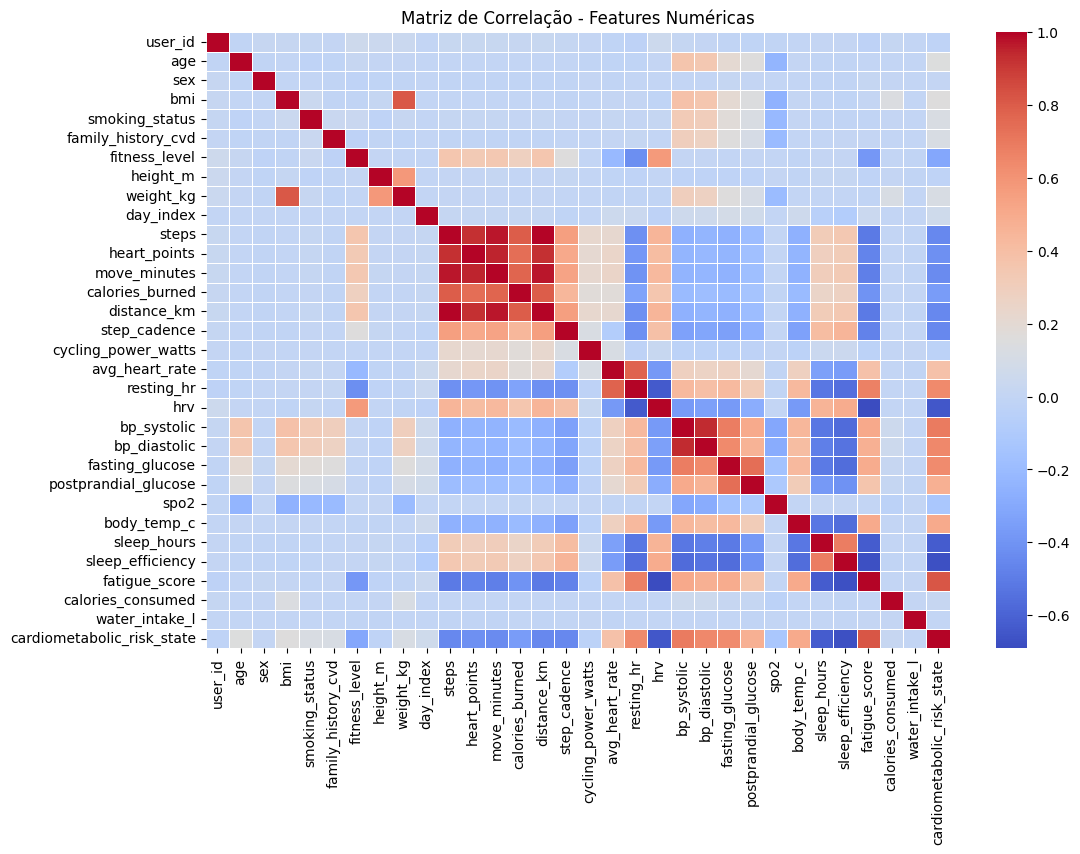

In [8]:
# Carrega o dataset
df = pd.read_csv('hamon_googlefit_medical_realistic.csv')

print("Shape do dataset:", df.shape)
print("\nDistribuição do target:")
print(df['cardiometabolic_risk_state'].value_counts().sort_index())

# === EDA ===
print("\n=== Valores nulos ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(df.describe().T[['mean', 'std', 'min', 'max']])

# Correlação (apenas numéricas)
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Matriz de Correlação - Features Numéricas')
plt.show()

## Etapa 2: Preparação dos Dados

**Porquê?**  
A preparação é a etapa mais demorada na prática (cerca de 80% do tempo). É necessário limpar dados, tratar missing values, codificar variáveis categóricas e separar treino/teste para evitar vazamento de informação.

**Como foi feito?**  
- Removemos colunas irrelevantes (user_id, date, day_index).  
- Tratamos missing values com mediana (numéricas) e moda (categóricas).  
- Codificamos a variável `activity_type` com LabelEncoder.  
- Dividimos os dados em treino e teste com `stratify=y` para manter o balanceamento das classes de risco.

In [6]:
target = 'cardiometabolic_risk_state'
X = df.drop(columns=[target, 'user_id', 'date', 'day_index'])
y = df[target]

# Tratamento de missing values (documentado)
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(include='object').columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

# Codifica activity_type
le = LabelEncoder()
X['activity_type'] = le.fit_transform(X['activity_type'])

# Separação treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape treino:", X_train.shape)
print("Shape teste:", X_test.shape)
print("Missing values restantes:", X_train.isnull().sum().sum())

Shape treino: (72000, 33)
Shape teste: (18000, 33)
Missing values restantes: 0


## Etapa 3: Escolha do Modelo

**Porquê?**  
Cada algoritmo tem vantagens e limitações. A escolha deve considerar interpretabilidade, tipo de problema (classificação multiclasse) e características dos dados (muitos missing values e variáveis mistas).

**Como foi feito?**  
Escolhemos a **Árvore de Decisão** porque é altamente interpretável, lida bem com dados mistos e missing values, e é rápida mesmo com 90 mil registros. Usamos `class_weight='balanced'` para lidar com o desbalanceamento do target.

In [11]:
modelo = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)
print("✅ Modelo Árvore de Decisão instanciado!")

✅ Modelo Árvore de Decisão instanciado!


## Etapa 4: Treinamento do Modelo

**Porquê?**  
É o momento em que o algoritmo aprende os padrões dos dados de treino, minimizando a impureza (Gini ou Entropy).

**Como foi feito?**  
Treinamos o modelo com `.fit(X_train, y_train)`. Depois analisamos a profundidade da árvore e a importância das features.

In [12]:
modelo.fit(X_train, y_train)

print("Profundidade da árvore:", modelo.get_depth())
print("Número de nós:", modelo.tree_.node_count)

importancias = pd.Series(modelo.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 5 features mais importantes:")
print(importancias.head(5))

Profundidade da árvore: 48
Número de nós: 22591

Top 5 features mais importantes:
fatigue_score    0.445860
age              0.060295
bmi              0.053799
fitness_level    0.042663
hrv              0.039877
dtype: float64


## Etapa 5: Avaliação do Modelo

**Porquê?**  
Treinar não é suficiente. Precisamos medir a performance em dados nunca vistos para garantir que o modelo generaliza bem.

**Como foi feito?**  
Calculamos acurácia, relatório de classificação e matriz de confusão. Também geramos o gráfico de Feature Importance e a visualização da árvore (limitada a profundidade 4 para legibilidade).

Acurácia: 0.7495

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.46      0.42      0.44       158
           1       0.72      0.71      0.72      5407
           2       0.78      0.79      0.78      9428
           3       0.45      0.44      0.45      1310
           4       0.92      0.92      0.92      1697

    accuracy                           0.75     18000
   macro avg       0.67      0.66      0.66     18000
weighted avg       0.75      0.75      0.75     18000



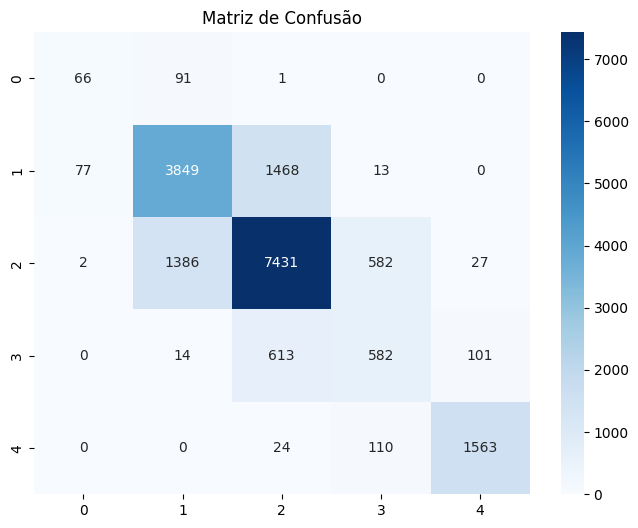

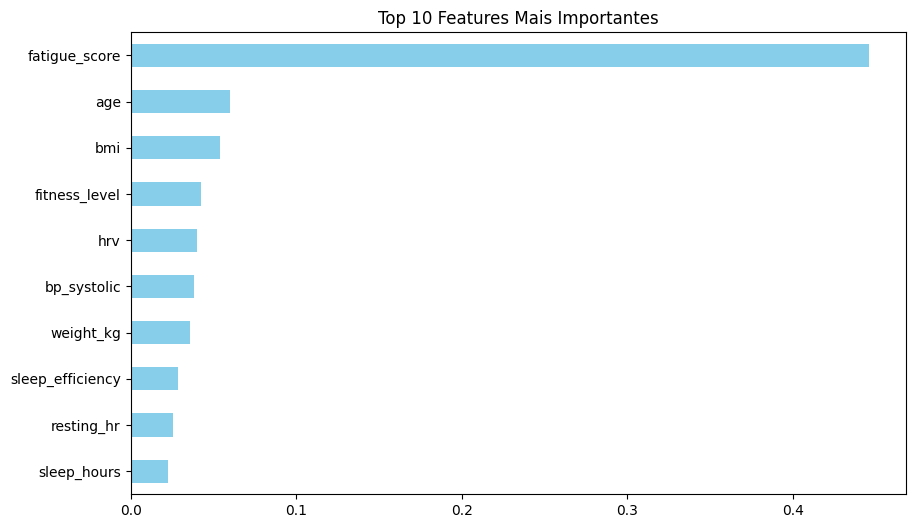

In [13]:
y_pred = modelo.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.show()

# Feature Importance
plt.figure(figsize=(10,6))
importancias.head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Features Mais Importantes')
plt.gca().invert_yaxis()
plt.show()

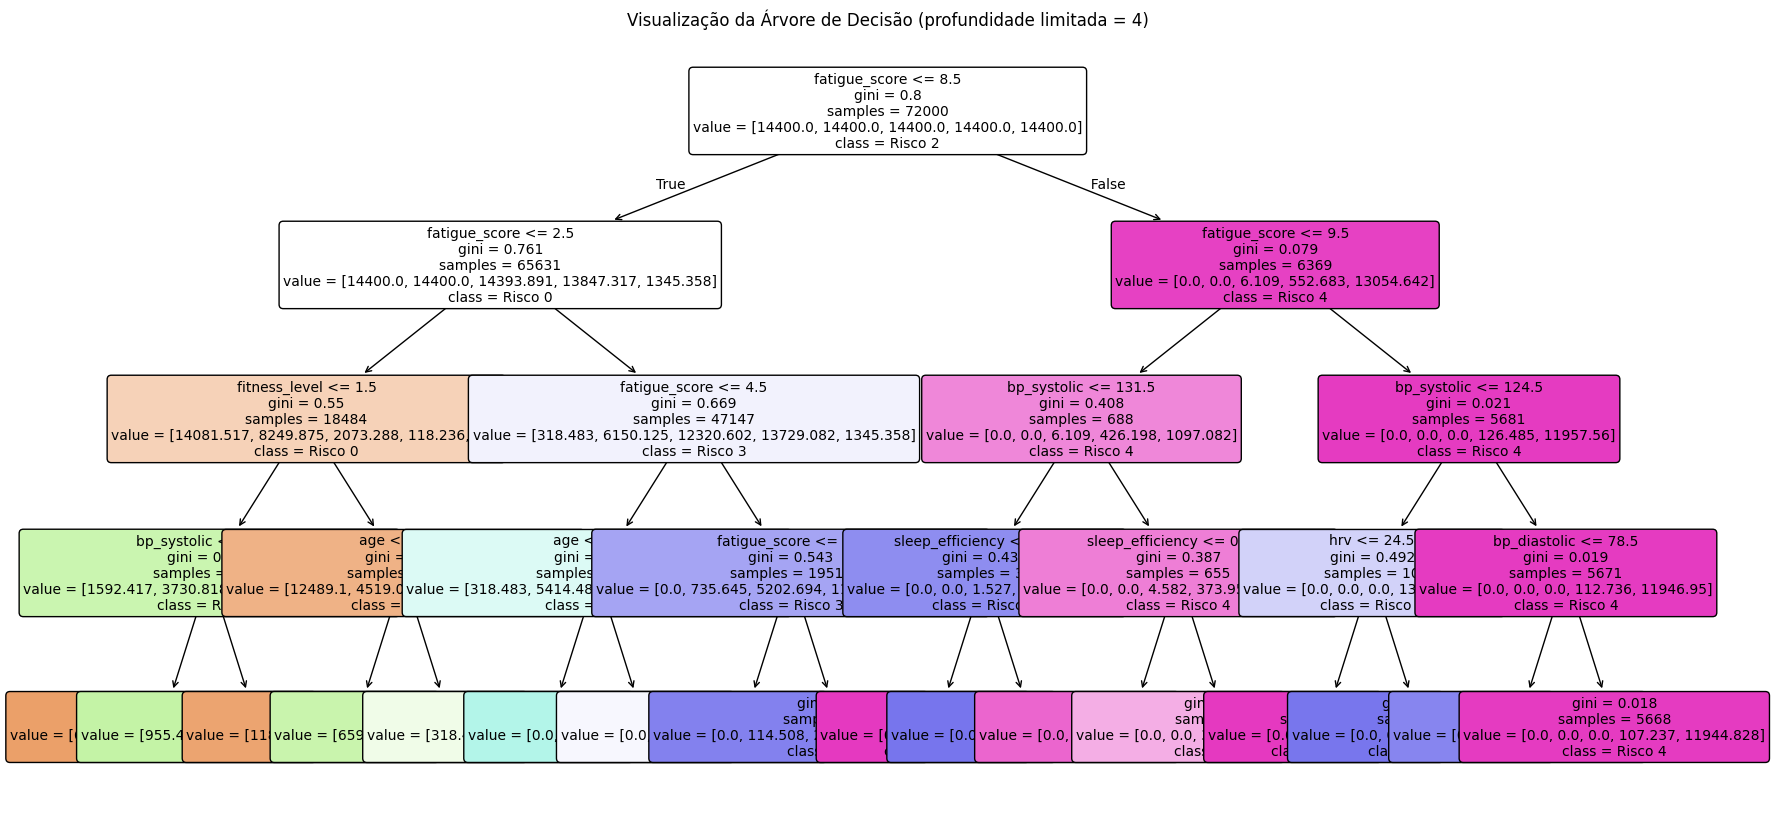

In [14]:
# Criamos uma árvore menor só para visualização (limitada)
tree_vis = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,           # limite para o gráfico ficar legível
    random_state=42,
    class_weight='balanced'
)

tree_vis.fit(X_train, y_train)

# Plot da árvore
plt.figure(figsize=(20, 10))
plot_tree(
    tree_vis,
    feature_names=X_train.columns,
    class_names=['Risco 0', 'Risco 1', 'Risco 2', 'Risco 3', 'Risco 4'],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=4
)
plt.title('Visualização da Árvore de Decisão (profundidade limitada = 4)')
plt.show()

## Etapa 6: Ajuste e Otimização

**Porquê?**  
O modelo inicial pode sofrer overfitting ou underfitting. O tuning busca o melhor equilíbrio de hiperparâmetros.

**Como foi feito?**  
Utilizamos GridSearchCV com validação cruzada (5-fold) e a métrica `f1_macro` (adequada para multiclasse desbalanceada).

In [ ]:
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Melhores parâmetros:", grid_search.best_params_)
melhor_modelo = grid_search.best_estimator_

## Etapa 7: Implantação e Monitoramento

**Porquê?**  
Um modelo só tem valor real quando colocado em produção e monitorado continuamente (data drift, mudança de comportamento dos usuários).

**Como foi feito?**  
Salvamos o modelo com joblib. Em produção, carregamos o modelo e fazemos predições em tempo real. O monitoramento envolve recalcular métricas periodicamente.

In [ ]:
# Salva o modelo treinado
joblib.dump(melhor_modelo, 'arvore_decisao_cardiometabolic_risk.pkl')
print("✅ Modelo salvo como 'arvore_decisao_cardiometabolic_risk.pkl'")

# Exemplo de uso em produção
modelo_carregado = joblib.load('arvore_decisao_cardiometabolic_risk.pkl')
nova_amostra = X_test.iloc[0:1].copy()
predicao = modelo_carregado.predict(nova_amostra)
print("Risco cardiometabólico previsto para a nova amostra:", predicao[0])

## Conclusão do Aluno

Este trabalho apresentou de forma clara e conceitual as **7 etapas do pipeline de Machine Learning**, utilizando um dataset real e complexo de saúde. A Árvore de Decisão foi escolhida pela sua alta interpretabilidade, permitindo explicar as decisões do modelo (ex.: “sono ruim + poucos passos → risco elevado”).

Apliquei todas as boas práticas vistas no curso: EDA, tratamento de missing values, stratify, tuning com GridSearchCV, feature importance e visualização da árvore.

**Rodrigo Ribeiro**  
Aluno de Ciências de Dados - Ebac